# Marketing Campaign Analysis

Objective: Analyze customer demographics and purchasing behavior to identify the characteristics of customers who are more likely to respond to marketing campaigns.

## 1. Import Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/marketingCampaign.csv', sep=';')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## Initial data exploration

In [25]:
df.describe() 

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [26]:
df.shape

(2240, 29)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Check missing values

In [28]:
dfNull = df.isnull().sum()
print(dfNull)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


## Check Duplicated Row

In [29]:
duplicatedRow = df.duplicated().sum()
print(duplicatedRow)

0


## Find Missing Value

In [30]:
missingRow = (
    df[
        (df['Income'].isnull())
    ]
)
missingRow

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,6,0,0,0,0,0,0,3,11,0


## Find Median Income

In [31]:
incomeMedian = df['Income'].median()
incomeMedian

np.float64(51381.5)

## Replace Null Values with Median Income

In [32]:
df['Income'] = df['Income'].fillna(incomeMedian)

## Campaign Response

In [33]:
campaignResponse = df['Response'].value_counts()
campaignResponse

Response
0    1906
1     334
Name: count, dtype: int64

## Find Campaign Reponse Rate

In [34]:
campaignResponseRate = (
    campaignResponse[1]/ df['ID'].count()
    ) * 100

campaignResponseRate

np.float64(14.910714285714285)

## Campaign Rate by Education 
Campaign response rates varied across education levels. Customers with higher education levels, such as Graduation and PhD, generally showed higher response rates compared with other groups.

This suggests that education level may be associated with different purchasing behaviors and engagement with marketing campaigns. However, education alone may not fully explain customer responses, and other factors such as income, spending patterns, and demographics should also be considered.

In [73]:
campaignRateByEducation = (
    df.groupby('Education')
    .agg(
        totalCustomers =('ID', 'count'),
        responseRate = ('Response', 'mean')
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)
campaignRateByEducation['responseRate'] = (
    campaignRateByEducation['responseRate'] * 100
).round()

campaignRateByEducation


,Education,totalCustomers,responseRate
4,PhD,486,21.0
3,Master,370,15.0
2,Graduation,1127,13.0
0,2n Cycle,203,11.0
1,Basic,54,4.0


## Create Income Groups Using Quantiles

In [71]:
q1 = df['Income'].quantile(0.25).round() # 35539
q2 = df['Income'].quantile(0.50).round() # 51382
q3 = df['Income'].quantile(0.75).round() # 68290

df['incomeGroup'] = np.where(
    df['Income'] >= q3, 
    'High', np.where(
        df['Income'] >= q2,
        'Medium', 'Low'
    )
)


## Campaign Response Rate by Income Group
Customers in the high-income group had the highest campaign response rate, while customers in the low-income group had the lowest response rate. The response rate generally increased as income increased.

This suggests that higher-income customers may have greater purchasing power and are more likely to engage with marketing campaigns. From a business perspective, high-income customers could represent an attractive target segment for future campaigns and personalized offers.

In [75]:
campaignRateByIncome = (
    df.groupby('incomeGroup')
    .agg(
        totalCustomers = ('ID', 'count'),
        responseRate = ('Response', 'mean')  
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)


campaignRateByIncome['responseRate'] = (
    campaignRateByIncome['responseRate'] * 100
    ).round() 


campaignRateByIncome

,incomeGroup,totalCustomers,responseRate
0,High,554,27.0
1,Low,1132,11.0
2,Medium,554,10.0


## Product Category Spending Analysis

In [83]:
df['totalSpending'] = (
    df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]
    .sum(axis=1)
)

df[['ID', 'totalSpending']].head()

,ID,totalSpending
0,5524,1617
1,2174,27
2,4141,776
3,6182,53
4,5324,422


## Analyze Campaign Response by Customer Spending Level

In [84]:
q1TotalSpending = df['totalSpending'].quantile(0.25).round() # 69
q2TotalSpending = df['totalSpending'].quantile(0.50).round() # 396
q3TotalSpending = df['totalSpending'].quantile(0.75).round() # 1046

df['spendingLevel'] = np.where(
    df['totalSpending'] >= q3TotalSpending,
    'High', np.where(df['totalSpending'] >= q2TotalSpending, 
    'Medium', 'Low'
    )
)

df['spendingLevel'].value_counts()

spendingLevel
Low       1118
Medium     562
High       560
Name: count, dtype: int64

## Campaign Response by Spending Level
Customers with no children at home had the highest campaign response rate. In general, customers with one or more children were less likely to respond to marketing campaigns.

This may suggest that customers with children have different priorities, less time to engage with marketing communications, or different purchasing behaviors. From a business perspective, campaigns targeting families may require different messaging or offers to improve engagement.

In [85]:
campaignRateBySpending = (
    df.groupby('spendingLevel')
    .agg(
        totalCustomers = ('ID', 'count'),
        totalResponses = ('Response', 'sum'),
        responseRate = ('Response', 'mean')
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)
campaignRateBySpending['responseRate'] = (
    campaignRateBySpending['responseRate'] * 100
).round()

campaignRateBySpending

,spendingLevel,totalCustomers,totalResponses,responseRate
0,High,560,168,30.0
2,Medium,562,66,12.0
1,Low,1118,100,9.0


## Campaign Response by Number of Children at Home

In [86]:
campaignRateByKidHome = (
    df.groupby('Kidhome')
    .agg(
        totalCustomers = ('ID', 'count'),
        totalResponses = ('Response', 'sum'),
        responseRate = ('Response', 'mean')
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)

campaignRateByKidHome['responseRate'] = (
    campaignRateByKidHome['responseRate'] * 100
).round()

campaignRateByKidHome

,Kidhome,totalCustomers,totalResponses,responseRate
0,0,1293,222,17.0
1,1,899,110,12.0
2,2,48,2,4.0


## Campaign Response by Number of Teen at Home
Customers with no teenagers at home had the highest campaign response rate at 20%. The response rate dropped significantly for customers with one teenager at home.

Although customers with two teenagers had a slightly higher response rate than those with one teenager, this group only consists of a small number of customers. Therefore, the difference may not be meaningful and should be interpreted with caution.

Overall, the results suggest that customers with teenagers at home are generally less likely to respond to marketing campaigns compared with customers without teenagers.

In [79]:
campaignRateByTeenHome = (
    df.groupby('Teenhome')
    .agg(
        totalCustomers = ('ID', 'count'),
        totalResponses = ('Response', 'sum'), 
        responseRate = ('Response', 'mean')
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)

campaignRateByTeenHome['responseRate'] = (
    campaignRateByTeenHome['responseRate'] * 100
).round()

campaignRateByTeenHome

,Teenhome,totalCustomers,totalResponses,responseRate
0,0,1158,237,20.0
2,2,52,5,10.0
1,1,1030,92,9.0


## Campaign Response by Marital Status
The Absurd and YOLO categories showed the highest campaign response rates. However, each group only contains two customers, making the results unreliable and not suitable for business conclusions.

Among the larger customer groups, response rates varied across marital statuses, suggesting that relationship status may influence customer engagement with marketing campaigns. However, further analysis is needed to understand the underlying reasons for these differences.

In [78]:
campaignRateByMarital = (
    df.groupby('Marital_Status')
    .agg(
        totalCustomers = ('ID', 'count'),
        totalResponses = ('Response', 'sum'), 
        responseRate = ('Response', 'mean')
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)
campaignRateByMarital['responseRate'] = (
    campaignRateByMarital['responseRate'] * 100
).round()

campaignRateByMarital

,Marital_Status,totalCustomers,totalResponses,responseRate
0,Absurd,2,1,50.0
7,YOLO,2,1,50.0
1,Alone,3,1,33.0
6,Widow,77,19,25.0
4,Single,480,106,22.0
2,Divorced,232,48,21.0
3,Married,864,98,11.0
5,Together,580,60,10.0


## Campaign Reponse by Recency
Customers who purchased more recently had the highest campaign response rate and also represented the largest customer group. This suggests that recently engaged customers are more likely to respond to marketing campaigns.

One possible explanation is that these customers are still actively engaged with the brand or recently made a purchase that increased their interest in promotional communications.

Customers in the less recent group had lower response rates. However, the reason cannot be determined from the data alone. Factors such as reduced engagement, changing customer needs, or other external factors may contribute to the lower response rate

In [64]:
df['Recency'].describe()

count    2240.000000
mean       49.109375
std        28.962453
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

In [65]:
q1Recency = df['Recency'].quantile(0.25).round()
q2Recency = df['Recency'].quantile(0.50).round()
q3Recency = df['Recency'].quantile(0.75).round()

df['recencyType'] = np.where(
    df['Recency'] >= q3Recency,
    'Less Recent', np.where(
        df['Recency'] >= q2Recency,
        'Medium', 'Recent'
    )
)

campaignRateByRecency = (
    df.groupby('recencyType')
    .agg(
        totalCustomers = ('ID', 'count'),
        totalResponses = ('Response', 'sum'),
        responseRate = ('Response', 'mean' )
    )
    .reset_index()
    .sort_values(by='responseRate', ascending=False)
)

campaignRateByRecency['responseRate'] = (
    campaignRateByRecency['responseRate'] * 100
).round()

campaignRateByRecency



,recencyType,totalCustomers,totalResponses,responseRate
2,Recent,1092,228,21.0
1,Medium,571,64,11.0
0,Less Recent,577,42,7.0


## Data Visualization

### Campaign Response Rate by Education

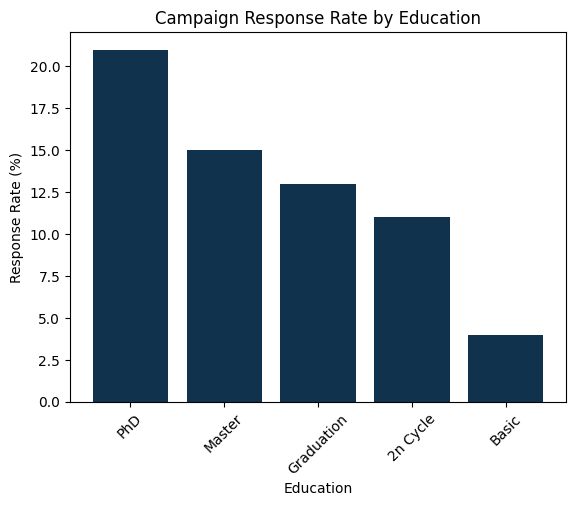

In [93]:
plt.bar(campaignRateByEducation['Education'], 
        campaignRateByEducation['responseRate'],
        color='#11324d')
plt.title('Campaign Response Rate by Education')
plt.xlabel('Education')
plt.ylabel('Response Rate (%)')
plt.xticks(rotation=45)
plt.show()

### Campaign Response Rate by Income Group

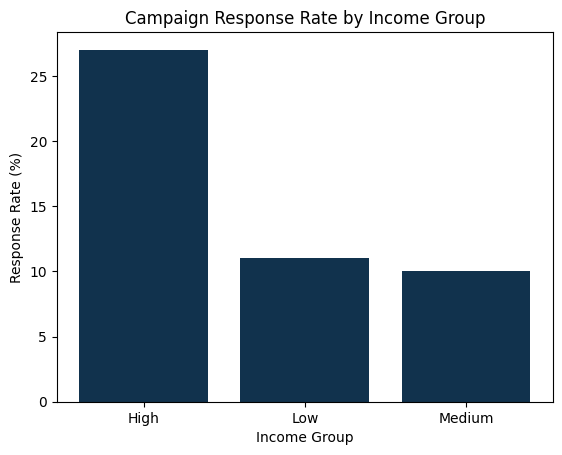

In [92]:
plt.bar(campaignRateByIncome['incomeGroup'],
        campaignRateByIncome['responseRate'],
        color='#11324d')
plt.title('Campaign Response Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Response Rate (%)')
plt.show()

### Campaign Response Rate by Spending Level


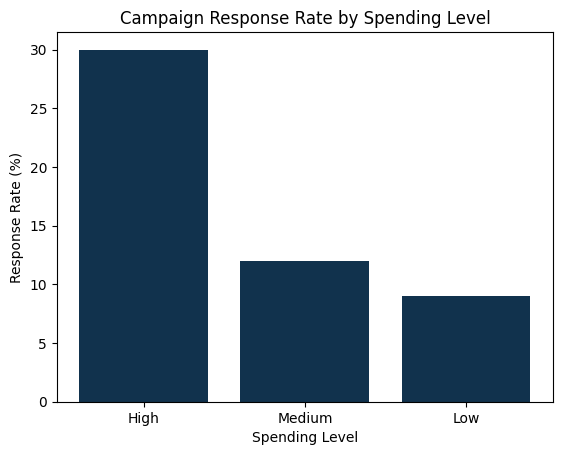

In [90]:
plt.bar(campaignRateBySpending['spendingLevel'],
        campaignRateBySpending['responseRate'], 
        color='#11324d')
plt.title('Campaign Response Rate by Spending Level')
plt.xlabel('Spending Level')
plt.ylabel('Response Rate (%)')
plt.show()

## Key Insights

- High-income customers showed the highest campaign response rates, suggesting that customers with greater purchasing power are more likely to engage with marketing campaigns.
- High spenders responded to campaigns more frequently than low spenders, making them an attractive target segment.
- Customers without children or teenagers at home generally had higher response rates than customers with children.
- Customers who purchased more recently responded better to campaigns, suggesting that recently engaged customers are more receptive to marketing communications.
- Although Absurd and YOLO had the highest response rates, both groups only contained two customers and should not be used for business conclusions.

## Recommendations

- Prioritize campaigns targeting high-income and high-spending customers as they are more likely to respond.
- Continue engaging recently active customers through personalized offers and promotions.
- Explore different messaging and offers for families with children, as they appear less responsive to current campaigns.
- Develop re-engagement campaigns for customers who have not purchased recently.
- Avoid making decisions based on customer groups with very small sample sizes.

## Executive Summary

This project analyzed customer demographics, spending behavior, and purchase recency to understand which customer segments are more likely to respond to marketing campaigns.

The analysis found that high-income, high-spending, and recently active customers had the highest response rates. Customers with children and teenagers at home generally responded less to campaigns. These findings suggest that customer segmentation can help businesses improve campaign performance by focusing on the customer groups that are most likely to engage.